In [35]:
import os
import numpy as np
import networkx as nx

from src.OrganoidMesh import OrganoidMesh
from src.cell_graph_functions import *
from src.nuclei_to_mesh_projection import *

In [36]:
def preprocess_single_organoid_graph(
    mesh_path,
    tp,
    well,
    cells_df,
    resolve_duplicates=True,
):
    """
    Build the cell adjacency graph for a single organoid and save to .npz.

    Returns
    -------
    G : networkx.Graph
    dist_mat : (V, N_cells) geodesic distances (if computed)
    vertex_owner : (V,)
    proj_vertex_ids : (N_cells,)
    """
    organoid_id = os.path.splitext(os.path.basename(mesh_path))[0]
    label_uid = f"{tp}_{well}_{organoid_id}"

    nuclei_df_org = cells_df[cells_df["label_uid"] == label_uid].copy()
    if nuclei_df_org.empty:
        print(f"  [WARN] No nuclei found for label_uid={label_uid}, skipping")
        return None, None, None, None

    # 1) load membrane mesh as an OrganoidMesh
    mesh = OrganoidMesh(mesh_path)

    # 2) extract per-cell attributes
    nuclei_xyz, markers_bin = extract_cell_attributes(nuclei_df_org)

    _, nuclei_xyz = center_and_rescale_mesh(mesh, nuclei_xyz)
    markers_bin = filter_lgr5_coexpression(markers_bin) 

    # 3) project nuclei -> mesh vertices (using geometry from the mesh object)
    proj_vertex_ids, proj_points = project_nuclei_to_mesh(
        nuclei_xyz,
        mesh,
        resolve_duplicates=resolve_duplicates,
    )

    # store eigen-decomposition for geodesics (if needed by compute_geodesics)
    mesh._eig_decomp()

    # 4) geodesic distances + Voronoi assignment
    dist_mat, vertex_owner = compute_geodesic_voronoi(mesh, proj_vertex_ids)

    # 5) build graph from Voronoi partition (now pass mesh, not mesh_f)
    G = build_cell_graph_from_voronoi(
        nuclei_xyz,
        markers_bin,
        mesh,            
        vertex_owner,
        proj_vertex_ids,
        proj_points,
    )

    G.graph["label_uid"] = label_uid   # store metadata in the graph object

    return G, dist_mat, vertex_owner, proj_vertex_ids, mesh


In [37]:
# ---------------------------------------------------------------------------
# Configuration / paths
# ---------------------------------------------------------------------------

data_dir = '../NicoleData/20250929/fractal_output'

# --- path to your cell nucleus table ---
CELLS_CSV = "../NicoleData/features_csv/features/cell_types_class.csv"   # <-- adjust

timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum_registered"
organoid_id = 19 #19 # example


path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"
cells_df = pd.read_csv(CELLS_CSV)

G, dist_mat, vertex_owner, proj_vertex_ids, mesh = preprocess_single_organoid_graph(path, timepoint, well, cells_df, resolve_duplicates=True)

Duplicate projections: none.


heat sources: 100%|██████████| 687/687 [00:03<00:00, 225.23it/s]


In [38]:
import plotly.graph_objects as go

# 3) Recover centroids and projected points from node attributes
nodes = sorted(G.nodes())  # should be [0, 1, ..., N_cells-1]

nuclei_xyz = np.array([G.nodes[n]["centroid"]   for n in nodes])  # (N_cells, 3)
proj_points = np.array([G.nodes[n]["proj_point"] for n in nodes])  # (N_cells, 3)

# For coloring the mesh: one label per vertex (Voronoi owner)
vertex_label_field = vertex_owner.astype(float)  # numeric for Plotly

print(np.unique(vertex_label_field).shape)
print(len(nodes))
print(len(proj_points))

# 4) Build the figure
fig = go.Figure(data=[
    # Surface colored by which cell owns each vertex
    go.Mesh3d(
        x=mesh.v[:, 0], y=mesh.v[:, 1], z=mesh.v[:, 2],
        i=mesh.f[:, 0], j=mesh.f[:, 1], k=mesh.f[:, 2],
        intensity=vertex_label_field,
        colorscale='Viridis',
        showscale=True,
        name="Surface Voronoi"
    ),

    # Projected points on the surface (red)
    go.Scatter3d(
        x=proj_points[:, 0],
        y=proj_points[:, 1],
        z=proj_points[:, 2],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name="Projected nuclei on surface"
    ),

    # True nucleus centroids in volume (blue)
    go.Scatter3d(
        x=nuclei_xyz[:, 0],
        y=nuclei_xyz[:, 1],
        z=nuclei_xyz[:, 2],
        mode='markers',
        marker=dict(size=6, color='blue', symbol='circle'),
        name="Nucleus centroids"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Projected nuclei on surface (red) vs cell centroids (blue)"
)

fig.show()


(687,)
687
687


In [39]:

# Build arrays for the connection segments
line_x = []
line_y = []
line_z = []

for p_nuc, p_proj in zip(nuclei_xyz, proj_points):
    line_x += [p_nuc[0], p_proj[0], None]
    line_y += [p_nuc[1], p_proj[1], None]
    line_z += [p_nuc[2], p_proj[2], None]

fig = go.Figure(data=[
    # Connection lines: nucleus -> projected point
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(width=2, color="rgba(0,0,0,0.5)"),  # semi-transparent gray
        name="Projection lines"
    ),

    # Projected points on the surface (red)
    go.Scatter3d(
        x=proj_points[:, 0],
        y=proj_points[:, 1],
        z=proj_points[:, 2],
        mode='markers',
        marker=dict(size=5, color='red', symbol='circle'),
        name="Projected nuclei on surface"
    ),

    # True nucleus centroids in volume (blue)
    go.Scatter3d(
        x=nuclei_xyz[:, 0],
        y=nuclei_xyz[:, 1],
        z=nuclei_xyz[:, 2],
        mode='markers',
        marker=dict(size=5, color='blue', symbol='circle'),
        name="Nucleus centroids"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Projected nuclei on surface (red) vs cell centroids (blue) with projection lines"
)

fig.show()


In [40]:
import numpy as np

# delta vectors from nuclei to projected surface points
delta = proj_points - nuclei_xyz    # (N_cells, 3)

# directional average magnitudes
avg_dx = np.mean(np.abs(delta[:, 0]))
avg_dy = np.mean(np.abs(delta[:, 1]))
avg_dz = np.mean(np.abs(delta[:, 2]))

# Euclidean lengths
proj_lengths = np.linalg.norm(delta, axis=1)
avg_proj_length = np.mean(proj_lengths)

print("Average |Δx|:", avg_dx)
print("Average |Δy|:", avg_dy)
print("Average |Δz|:", avg_dz)
print("Average Euclidean projection length:", avg_proj_length)


Average |Δx|: 0.3049527591658418
Average |Δy|: 0.21441483154518481
Average |Δz|: 0.35767263578701597
Average Euclidean projection length: 0.5946511249009123


In [41]:

from src.organoid_plotting import plot_organoid_graph


nodes = sorted(G.nodes())
centroids = np.array([G.nodes[n]["centroid"] for n in nodes])
# centroids = np.array([G.nodes[n]["proj_point"] for n in nodes])  # (N_cells, 3)
markers_bin = np.array([G.nodes[n]["markers_bin"] for n in nodes])

n_cells = markers_bin.shape[0]   # number of nodes

colors = np.full(n_cells, "darkgray", dtype=object)  # baseline: one color per node

colors[markers_bin[:,0] == 1] = "#1f77b4"   # blue
colors[markers_bin[:,4] == 1] = "#2ca02c"   # green
colors[markers_bin[:,8] == 1] = "#d62728"   # red
colors[markers_bin[:,9] == 1] = "#9467bd"   # purple


print(centroids.shape)
print(markers_bin.shape)


fig = plot_organoid_graph(
    centroids,
    G,
    node_values=colors,   # <--- important
    node_size=5,
    edge_width=3.0,
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-0.8, y=-0.8, z=1.2)   # position of the camera
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)

legend_traces = [
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#1f77b4"),
        name="stem cell (LGR5+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#d62728"),
        name="enterochromaffin (Serotonin+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#2ca02c"),
        name="absorptive (AldoB+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#9467bd"),
        name="paneth (Lysozyme+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color='darkgray'),
        name="other",
        showlegend=True
    ),
]

for tr in legend_traces:
    fig.add_trace(tr)

fig.update_layout(height=550, width=750)
fig.show()


(687, 3)
(687, 10)


### Load vocab and project to graph

In [42]:
from src.mesh_analysis import compute_hks

# loads the vocab from file
res = np.load('./sim/vocab.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item()
sigma = res['sigma']
ts = res['ts']

print(ts)

hks = compute_hks(mesh, ts, coeffs=False)

print(hks.shape)

# normalise
normalised_hks = (hks/np.mean(hks, axis=0, keepdims=True) - 1)
normalised_hks = scaler.transform(normalised_hks)

# convert to encoding
dist = np.linalg.norm(normalised_hks[:, np.newaxis, :]-vocab[np.newaxis, :, :], axis=2)
encoding = np.exp(-dist**2 / (2 * sigma**2))

print(encoding.shape)

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator Normalizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



[  1.           1.27427499   1.62377674   2.06913808   2.6366509
   3.35981829   4.2813324    5.45559478   6.95192796   8.8586679
  11.28837892  14.38449888  18.32980711  23.35721469  29.76351442
  37.92690191  48.32930239  61.58482111  78.47599704 100.        ]
(18001, 20)
(18001, 8)


/tmp/ipykernel_2102692/1317945980.py:7: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



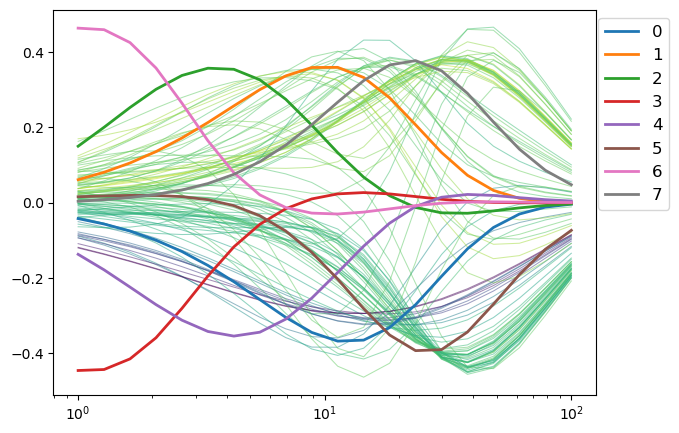

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

random_indices = np.random.choice(hks.shape[0], size=100, replace=False)
norm = Normalize(vmin=hks[:, 0].min(), vmax=hks[:, 0].max())
cmap = cm.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(7, 5))

for ind in random_indices:
    ax.plot(ts, normalised_hks[ind], color=cmap(norm(hks[ind, 0])), alpha=0.5, linewidth=0.75)

for i in range(len(vocab)):
    center = vocab[i]
    ax.plot(ts, center, '-', linewidth=2, label=f'{i}')

plt.xscale('log')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=12)
# plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='HKS at t=1')
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# vocab_plot_idx = [1, 5, 7]
vocab_plot_idx = [0,3,4,5] # neck and villus
# vocab_plot_idx = [1, 2, 7] # crypt


# --- Create subplot figure ---
fig = make_subplots(
    rows=1, cols=len(vocab_plot_idx),
    specs=[[{'type': 'mesh3d'}] * len(vocab_plot_idx)],
    subplot_titles=vocab_plot_idx
)

# --- Add each marker as a Mesh3d trace ---
for i, idx in enumerate(vocab_plot_idx, start=1):
    fig.add_trace(
        go.Mesh3d(
            x=mesh.v[:, 0], y=mesh.v[:, 1], z=mesh.v[:, 2],
            i=mesh.f[:, 0], j=mesh.f[:, 1], k=mesh.f[:, 2],
            intensity=encoding[:, idx],
            colorscale='Viridis',
            showscale=True,
            name=f"Vocab {idx}"
        ),
        row=1, col=i
    )


fig.show()

In [45]:
# Add the encoding field to the graph
add_vertex_field_to_graph(G, encoding, 'vocab_encoding')

encoding_nodes = np.array([G.nodes[n]["vocab_encoding"] for n in nodes])

for idx in vocab_plot_idx:
    node_values = encoding_nodes[:, idx]     # shape (N_cells,)

    fig = plot_organoid_graph(
        centroids,
        G,
        node_values=node_values,   # <--- numeric, not strings
        node_size=5,
        edge_width=3.0,
        colorscale="Viridis",      # <-- enable colorscale
    )

    fig.show()
